In [1]:
import os
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Any, Tuple, Optional, List

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Для Windows: num_workers=0 по умолчанию (чтобы избежать проблем с multiprocessing)
DEFAULT_NUM_WORKERS = 0

# Быстрый режим (рекомендуется для семинара/проверки)
FAST_MODE = True

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def maybe_subset(ds, max_items: Optional[int], seed: int = 42):
    if max_items is None:
        return ds
    n = len(ds)
    if max_items >= n:
        return ds
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_items, replace=False)
    return Subset(ds, idx.tolist())

from pathlib import Path
import json

np.random.seed(42)
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
results_columns = [
    "experiment_id", "dataset", "seed", "model_summary",
    "optimizer", "lr", "momentum", "weight_decay",
    "epochs_trained", "best_val_accuracy", "best_val_loss"
]
results_df = pd.DataFrame(columns=results_columns)

results_path = ARTIFACTS_DIR / "runs.csv"
results_df.to_csv(results_path, index=False)

figures_dir = Path("artifacts/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
set_seed(42)
device = get_device()
device

device(type='cuda')

In [2]:
import torchvision
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, split="balanced", download=True, transform=transform 
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, split="balanced", download=True, transform=transform
)

class_names = train_full.classes
print("Name of classes:", class_names)
print("Train size:",len( train_full))
print("Test size:", len(test_ds))

Name of classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
Train size: 112800
Test size: 18800


In [3]:
def make_loaders(ds_train_full, ds_test, batch_size: int = 512, val_ratio: float = 0.2, seed: int = 42):
    n_total = len(ds_train_full)
    n_val = max(1, int(n_total * val_ratio))
    n_train = n_total - n_val

    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=gen)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(train_full, test_ds, batch_size=128)

# sanity-check
x, y = next(iter(train_loader))
x.shape, y.shape, x.min().item(), x.max().item()


(torch.Size([128, 1, 28, 28]), torch.Size([128]), -1.0, 1.0)

In [ ]:
class MLP(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.hidden_sizes = hidden_sizes
        self.activation = activation
        self.use_batchnorm = use_batchnorm
        self.dropout = dropout

        c, h, w = input_shape
        in_features = c * h * w

        act_layer = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "gelu": nn.GELU,
        }.get(activation.lower(), nn.ReLU)

        layers: List[nn.Module] = [nn.Flatten()]

        prev = in_features
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))
            layers.append(act_layer())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hs

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
    

In [5]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def grad_global_norm(parameters) -> float:
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return math.sqrt(total_norm_sq)

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    grad_norms_before = []
    grad_norms_after = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        
        if not torch.isfinite(loss):
            continue

        loss.backward()

        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)

        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    avg_loss = total_loss / max(1, n)
    avg_acc = total_acc / max(1, n)

    out = {"loss": float(avg_loss), "acc": float(avg_acc)}
    if log_grad_norm:
        out["grad_norm_before_mean"] = float(np.mean(grad_norms_before)) if grad_norms_before else None
        if max_grad_norm is not None:
            out["grad_norm_after_mean"] = float(np.mean(grad_norms_after)) if grad_norms_after else None
    return out

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return {"loss": float(total_loss / max(1, n)), "acc": float(total_acc / max(1, n))}

def plot_history(history: Dict[str, List[float]], title: str = ""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(list(epochs), history["train_loss"], label="train_loss")
    plt.plot(list(epochs), history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title or "Loss curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(list(epochs), history["train_acc"], label="train_acc")
    plt.plot(list(epochs), history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title or "Accuracy curves")
    plt.legend()
    plt.show()

In [6]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [7]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_stats = evaluate(model, val_loader, criterion, device)
        
        tr_loss = train_stats["loss"]
        tr_acc = train_stats["acc"]
        va_loss = val_stats["loss"]
        va_acc = val_stats["acc"]

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={float(tr_loss):.4f}, acc={float(tr_acc):.4f} | "
                f"val loss={float(va_loss):.4f}, acc={float(va_acc):.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

1. E1(baseline)

epoch 01/20 | train loss=1.3019, acc=0.6278 | val loss=0.8890, acc=0.7316
epoch 02/20 | train loss=0.7287, acc=0.7712 | val loss=0.6880, acc=0.7837
epoch 03/20 | train loss=0.5979, acc=0.8057 | val loss=0.6018, acc=0.8059
epoch 04/20 | train loss=0.5307, acc=0.8235 | val loss=0.5667, acc=0.8192
epoch 05/20 | train loss=0.4905, acc=0.8350 | val loss=0.5338, acc=0.8277
epoch 06/20 | train loss=0.4593, acc=0.8422 | val loss=0.5253, acc=0.8258
epoch 07/20 | train loss=0.4356, acc=0.8485 | val loss=0.5187, acc=0.8276
epoch 08/20 | train loss=0.4126, acc=0.8548 | val loss=0.5128, acc=0.8333
epoch 09/20 | train loss=0.3929, acc=0.8602 | val loss=0.5129, acc=0.8350
epoch 10/20 | train loss=0.3790, acc=0.8634 | val loss=0.5168, acc=0.8316
epoch 11/20 | train loss=0.3646, acc=0.8678 | val loss=0.5121, acc=0.8376
epoch 12/20 | train loss=0.3529, acc=0.8707 | val loss=0.5152, acc=0.8345
epoch 13/20 | train loss=0.3399, acc=0.8748 | val loss=0.5212, acc=0.8381
epoch 14/20 | train loss=0.3299, acc=0

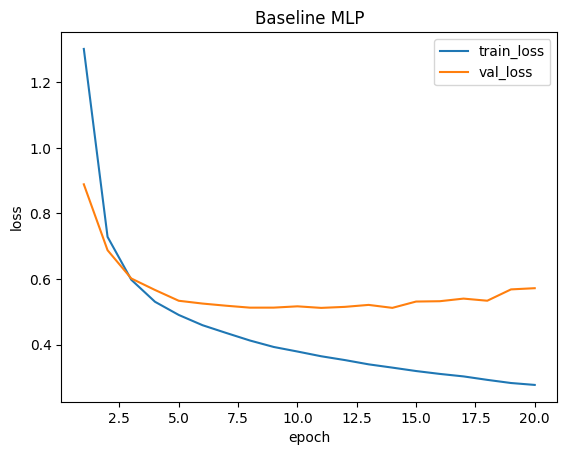

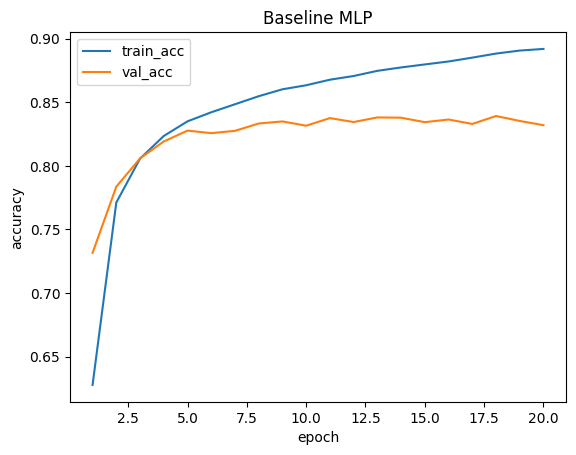

In [8]:
set_seed(42)
baseline = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], num_classes=len(class_names), dropout=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

2. E2(dropout)

epoch 01/20 | train loss=1.8898, acc=0.4583 | val loss=1.0426, acc=0.6973
epoch 02/20 | train loss=1.2759, acc=0.6173 | val loss=0.8582, acc=0.7399
epoch 03/20 | train loss=1.1497, acc=0.6494 | val loss=0.7873, acc=0.7548
epoch 04/20 | train loss=1.0818, acc=0.6662 | val loss=0.7292, acc=0.7725
epoch 05/20 | train loss=1.0373, acc=0.6782 | val loss=0.7058, acc=0.7754
epoch 06/20 | train loss=1.0149, acc=0.6844 | val loss=0.6921, acc=0.7774
epoch 07/20 | train loss=0.9902, acc=0.6917 | val loss=0.6752, acc=0.7877
epoch 08/20 | train loss=0.9708, acc=0.6958 | val loss=0.6675, acc=0.7857
epoch 09/20 | train loss=0.9514, acc=0.7010 | val loss=0.6383, acc=0.7961
epoch 10/20 | train loss=0.9352, acc=0.7054 | val loss=0.6278, acc=0.7963
epoch 11/20 | train loss=0.9317, acc=0.7072 | val loss=0.6307, acc=0.7977
epoch 12/20 | train loss=0.9233, acc=0.7080 | val loss=0.6290, acc=0.7984
epoch 13/20 | train loss=0.9093, acc=0.7132 | val loss=0.6186, acc=0.8006
epoch 14/20 | train loss=0.9050, acc=0

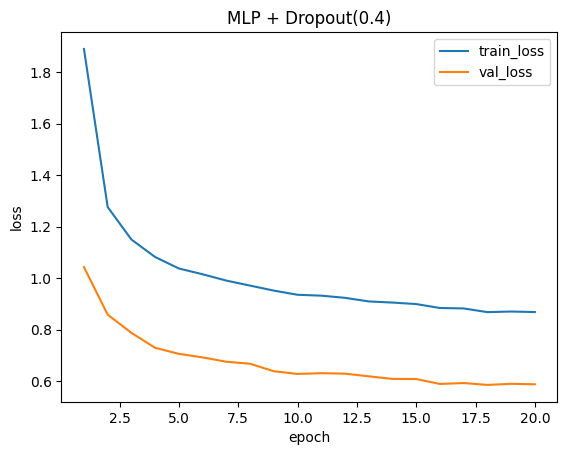

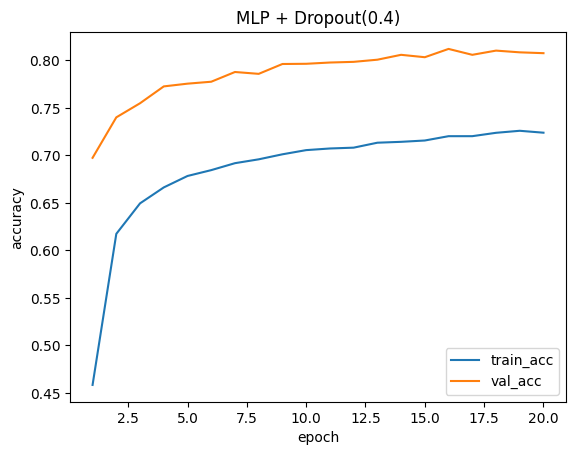

In [9]:
set_seed(42)
dropout_model = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], num_classes=len(class_names), dropout=0.4, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.4)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)

все плохо, модель не учится обобщать, она просто запоминает.

3. E3

epoch 01/20 | train loss=0.9957, acc=0.7282 | val loss=0.6002, acc=0.8100
epoch 02/20 | train loss=0.5281, acc=0.8255 | val loss=0.5110, acc=0.8317
epoch 03/20 | train loss=0.4497, acc=0.8465 | val loss=0.4897, acc=0.8376
epoch 04/20 | train loss=0.4021, acc=0.8595 | val loss=0.4761, acc=0.8402
epoch 05/20 | train loss=0.3702, acc=0.8696 | val loss=0.4727, acc=0.8387
epoch 06/20 | train loss=0.3426, acc=0.8750 | val loss=0.4639, acc=0.8450
epoch 07/20 | train loss=0.3231, acc=0.8818 | val loss=0.4659, acc=0.8474
epoch 08/20 | train loss=0.3050, acc=0.8859 | val loss=0.4633, acc=0.8468
epoch 09/20 | train loss=0.2876, acc=0.8916 | val loss=0.4664, acc=0.8484
epoch 10/20 | train loss=0.2736, acc=0.8960 | val loss=0.4721, acc=0.8493
epoch 11/20 | train loss=0.2616, acc=0.8994 | val loss=0.4796, acc=0.8478
epoch 12/20 | train loss=0.2480, acc=0.9047 | val loss=0.4903, acc=0.8438
epoch 13/20 | train loss=0.2372, acc=0.9077 | val loss=0.5020, acc=0.8453
epoch 14/20 | train loss=0.2304, acc=0

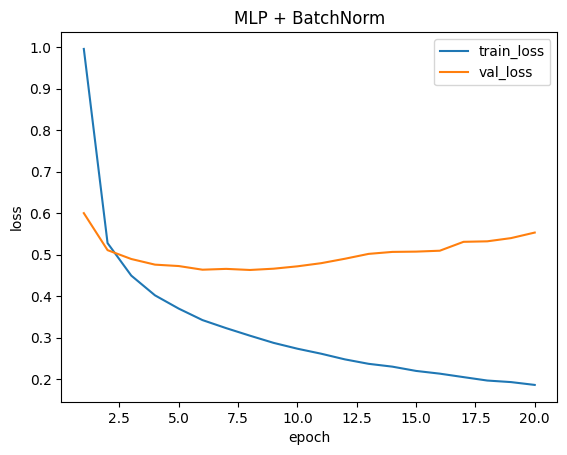

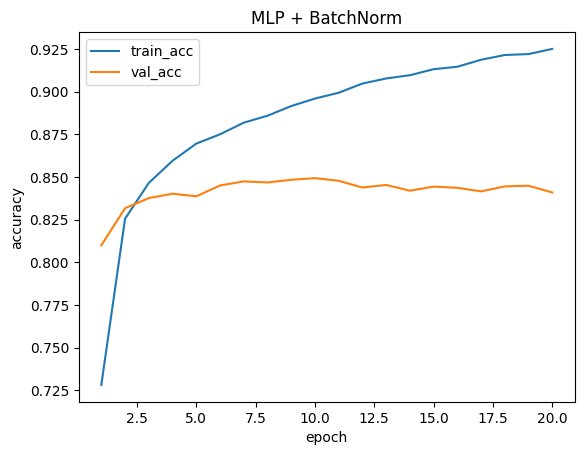

In [10]:
set_seed(42)
batchnorm_model = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], num_classes=len(class_names), dropout=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(batchnorm_model.parameters(), lr=1e-3)

history_batchnorm = fit(
    batchnorm_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_batchnorm, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)

epoch 01/50 | train loss=1.5826, acc=0.5656 | val loss=0.8124, acc=0.7518
epoch 02/50 | train loss=1.0201, acc=0.6871 | val loss=0.6622, acc=0.7898
epoch 03/50 | train loss=0.9005, acc=0.7176 | val loss=0.5951, acc=0.8109
epoch 04/50 | train loss=0.8348, acc=0.7349 | val loss=0.5669, acc=0.8137
epoch 05/50 | train loss=0.7969, acc=0.7465 | val loss=0.5405, acc=0.8176
epoch 06/50 | train loss=0.7628, acc=0.7557 | val loss=0.5258, acc=0.8248
epoch 07/50 | train loss=0.7435, acc=0.7609 | val loss=0.5109, acc=0.8293
epoch 08/50 | train loss=0.7201, acc=0.7661 | val loss=0.4992, acc=0.8323
epoch 09/50 | train loss=0.7126, acc=0.7675 | val loss=0.5003, acc=0.8318
epoch 10/50 | train loss=0.6976, acc=0.7716 | val loss=0.4940, acc=0.8336
epoch 11/50 | train loss=0.6849, acc=0.7763 | val loss=0.4806, acc=0.8380
epoch 12/50 | train loss=0.6777, acc=0.7771 | val loss=0.4769, acc=0.8381
epoch 13/50 | train loss=0.6686, acc=0.7803 | val loss=0.4733, acc=0.8404
epoch 14/50 | train loss=0.6633, acc=0

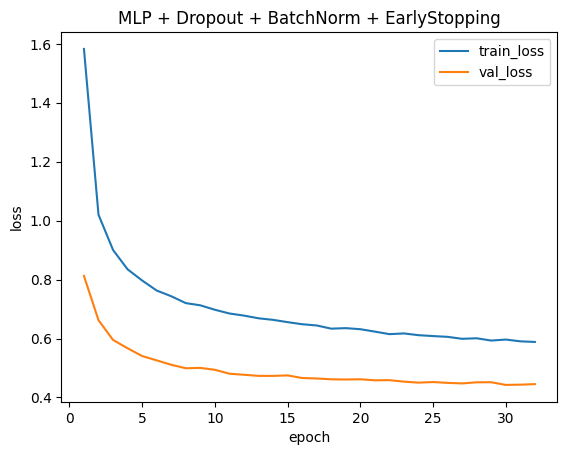

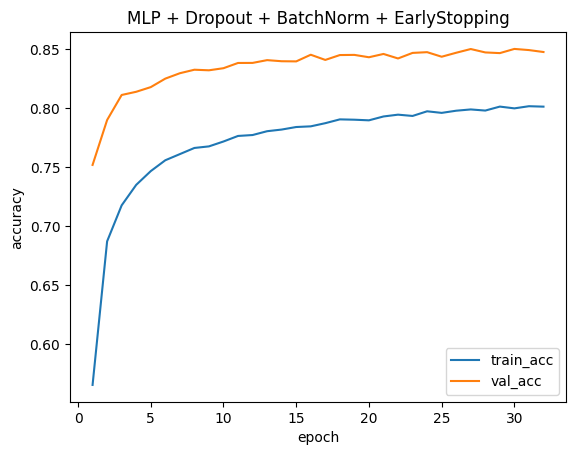

<Figure size 640x480 with 0 Axes>

Best model curves saved to artifacts\figures\curves_best.png


In [11]:
set_seed(42)
combo_model = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], num_classes=len(class_names), dropout=0.4, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=5, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50, 
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
plot_path_best = figures_dir / "curves_best.png"
plt.savefig(plot_path_best, dpi=150, bbox_inches='tight')
plt.show()
print(f"Best model curves saved to {plot_path_best}")


In [12]:
best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": 42,
    "model_architecture": {
        "input_shape": [1, 28, 28],
        "num_classes": 47,
        "hidden_sizes": [256, 128],
        "activation": "relu",
        "dropout": 0.4,
        "use_batchnorm": True
    },
    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": 128,
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 0.0005,
        "epochs_trained": len(history_combo['train_loss'])
    },
    "best_val_accuracy": max(history_combo['val_acc']),
    "best_val_loss": min(history_combo['val_loss'])
}

config_path = ARTIFACTS_DIR / "best_config.json"
with open(config_path, 'w') as f:
    json.dump(best_config, f, indent=4)
print(f"Best config saved to {config_path}")

Best config saved to artifacts\best_config.json


In [13]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)["acc"],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)["acc"],
    "batchnorm": evaluate(batchnorm_model, test_loader, nn.CrossEntropyLoss(), device)["acc"],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)["acc"],
}
for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.8294
  dropout: test_acc=0.8054
batchnorm: test_acc=0.8410
    combo: test_acc=0.8428


4.O1 (LR слишком большой)

epoch 01/8 | train loss=1.9641, acc=0.4295 | val loss=1.1035, acc=0.6383
epoch 02/8 | train loss=1.6070, acc=0.5144 | val loss=0.8985, acc=0.7069
epoch 03/8 | train loss=1.5277, acc=0.5339 | val loss=0.8994, acc=0.7075
epoch 04/8 | train loss=1.5161, acc=0.5355 | val loss=0.8820, acc=0.7057
epoch 05/8 | train loss=1.4905, acc=0.5425 | val loss=0.8103, acc=0.7375
epoch 06/8 | train loss=1.4410, acc=0.5531 | val loss=0.8080, acc=0.7394
epoch 07/8 | train loss=1.4307, acc=0.5584 | val loss=0.8335, acc=0.7375
epoch 08/8 | train loss=1.3972, acc=0.5671 | val loss=0.7798, acc=0.7494


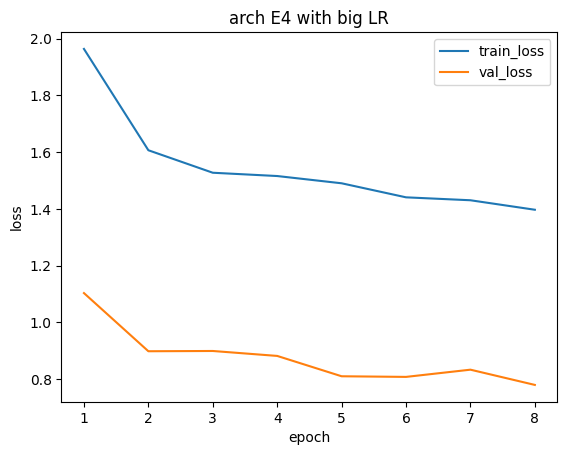

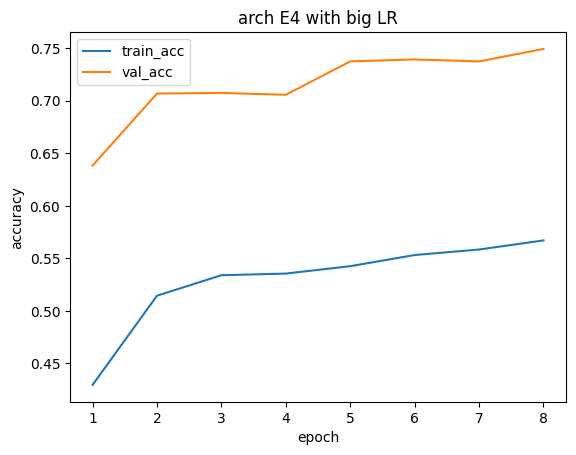

In [14]:
set_seed(42)
model_o1 = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], 
               num_classes=len(class_names), dropout=0.4, use_batchnorm=True).to(device)
optimizer_o1 = torch.optim.Adam(model_o1.parameters(), lr=1e-1)

history_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, criterion, device, epochs=8)
plot_history(history_o1, title="arch E4 with big LR")
test_loss_o1, test_acc_o1 = evaluate(model_o1, test_loader, criterion, device)

5. O2 (маленький LR)

epoch 01/8 | train loss=3.7665, acc=0.0590 | val loss=3.4552, acc=0.2125
epoch 02/8 | train loss=3.4129, acc=0.1547 | val loss=3.1694, acc=0.3458
epoch 03/8 | train loss=3.1748, acc=0.2383 | val loss=2.9628, acc=0.4217
epoch 04/8 | train loss=2.9914, acc=0.3024 | val loss=2.7852, acc=0.4713
epoch 05/8 | train loss=2.8314, acc=0.3504 | val loss=2.6278, acc=0.5040
epoch 06/8 | train loss=2.6952, acc=0.3875 | val loss=2.4919, acc=0.5295
epoch 07/8 | train loss=2.5687, acc=0.4186 | val loss=2.3656, acc=0.5556
epoch 08/8 | train loss=2.4553, acc=0.4427 | val loss=2.2442, acc=0.5744


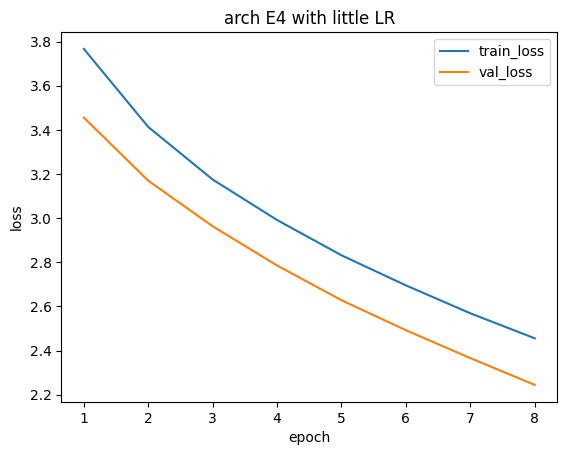

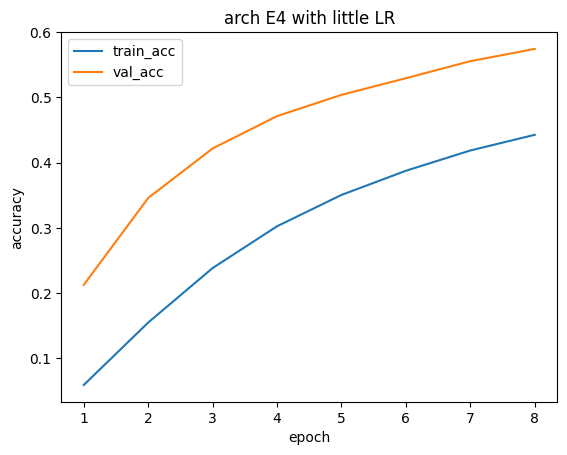

In [15]:
set_seed(42)
model_o2 = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], 
               num_classes=len(class_names), dropout=0.4, use_batchnorm=True).to(device)
optimizer_o2 = torch.optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=8)
plot_history(history_o2, title="arch E4 with little LR")
test_loss_o2, test_acc_o2 = evaluate(model_o2, test_loader, criterion, device)


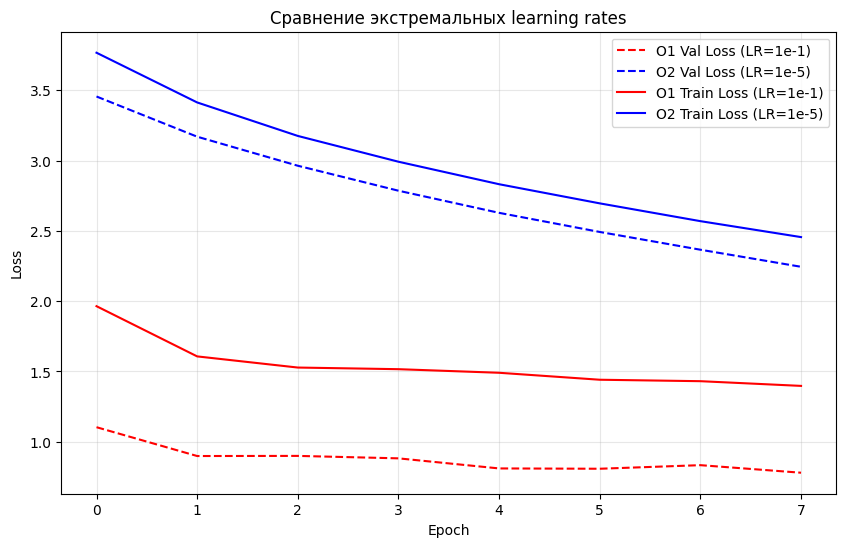

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(history_o1['val_loss'], label='O1 Val Loss (LR=1e-1)', color='red', linestyle='--')
plt.plot(history_o2['val_loss'], label='O2 Val Loss (LR=1e-5)', color='blue', linestyle='--')
plt.plot(history_o1['train_loss'], label='O1 Train Loss (LR=1e-1)', color='red')
plt.plot(history_o2['train_loss'], label='O2 Train Loss (LR=1e-5)', color='blue')

plt.title('Сравнение экстремальных learning rates')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plot_path_lr_alt = figures_dir / "curves_lr_extremes_alt.png"
plt.savefig(plot_path_lr_alt, dpi=150, bbox_inches='tight')
plt.show()

6. O3(SGD + momentum)

epoch 01/15 | train loss=1.7148, acc=0.5282 | val loss=0.8946, acc=0.7353
epoch 02/15 | train loss=1.1285, acc=0.6576 | val loss=0.7331, acc=0.7734
epoch 03/15 | train loss=0.9972, acc=0.6912 | val loss=0.6497, acc=0.7962
epoch 04/15 | train loss=0.9175, acc=0.7131 | val loss=0.6127, acc=0.8047
epoch 05/15 | train loss=0.8690, acc=0.7274 | val loss=0.5844, acc=0.8085
epoch 06/15 | train loss=0.8318, acc=0.7362 | val loss=0.5610, acc=0.8161
epoch 07/15 | train loss=0.8020, acc=0.7453 | val loss=0.5449, acc=0.8215
epoch 08/15 | train loss=0.7804, acc=0.7498 | val loss=0.5286, acc=0.8259
epoch 09/15 | train loss=0.7636, acc=0.7546 | val loss=0.5219, acc=0.8263
epoch 10/15 | train loss=0.7412, acc=0.7597 | val loss=0.5137, acc=0.8305
epoch 11/15 | train loss=0.7359, acc=0.7617 | val loss=0.5074, acc=0.8304
epoch 12/15 | train loss=0.7234, acc=0.7656 | val loss=0.5000, acc=0.8304
epoch 13/15 | train loss=0.7130, acc=0.7686 | val loss=0.5017, acc=0.8324
epoch 14/15 | train loss=0.7050, acc=0

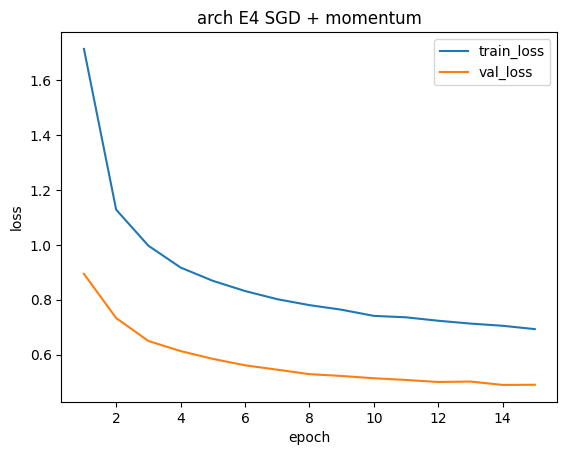

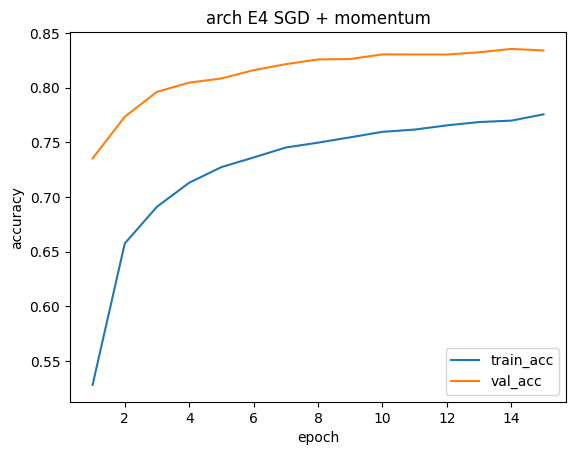

In [17]:
set_seed(42)
model_o3 = MLP(hidden_sizes=(256, 128), input_shape=[1, 28, 28], 
               num_classes=len(class_names), dropout=0.4, use_batchnorm=True).to(device)
optimizer_o3 = torch.optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=15)
plot_history(history_o3, title="arch E4 SGD + momentum")
test_loss_o3, test_acc_o3 = evaluate(model_o3, test_loader, criterion, device)

In [29]:
results = evaluate(combo_model, test_loader, criterion, device)
test_loss = results['loss']
test_acc = results['acc']

print(f"Final Test Accuracy for best model (E4): {test_acc:.4f}")
print(f"Final Test Loss for best model (E4): {test_loss:.4f}")

test_result_path = ARTIFACTS_DIR / "test_result.txt"
with open(test_result_path, 'w') as f:
    f.write(f"Best Model (E4) - Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Best Model (E4) - Test Loss: {test_loss:.4f}\n")

Final Test Accuracy for best model (E4): 0.8428
Final Test Loss for best model (E4): 0.4667


In [ ]:
def save_experiment_result(experiment_id, model, history, optimizer, model_summary=None, **kwargs):
        if model_summary is None and model is not None:
    
            hidden_sizes = getattr(model, 'hidden_sizes', '?')
            dropout = getattr(model, 'dropout', 0)
            use_bn = getattr(model, 'use_batchnorm', False)
            activation = getattr(model, 'activation', 'relu')
        
            bn_str = ", BN" if use_bn else ", no BN"
            dropout_str = f", dropout={dropout}" if dropout > 0 else ", no dropout"
            model_summary = f"MLP {hidden_sizes}, {activation}{bn_str}{dropout_str}"
    
   
        opt_name = optimizer.__class__.__name__
        lr = optimizer.param_groups[0]['lr']
        momentum = optimizer.param_groups[0].get('momentum', 0)
        weight_decay = optimizer.param_groups[0].get('weight_decay', 0)
    
    
        new_row_data = {
            "experiment_id": experiment_id,
            "dataset": kwargs.get('dataset', 'EMNIST'),
            "seed": kwargs.get('seed', 42),
            "model_summary": model_summary,
            "optimizer": opt_name,
            "lr": lr,
            "momentum": momentum if opt_name == 'SGD' else 0,
            "weight_decay": weight_decay,
            "epochs_trained": len(history['train_loss']),
            "best_val_accuracy": max(history['val_acc']),
            "best_val_loss": min(history['val_loss'])
        }
    
    
        if 'test_acc' in kwargs:
            new_row_data['test_accuracy'] = kwargs['test_acc']
    
    
        new_row = pd.DataFrame([new_row_data])
    
    
        results_path = ARTIFACTS_DIR / "runs.csv"
        if results_path.exists():
            results_df = pd.read_csv(results_path)
            results_df = pd.concat([results_df, new_row], ignore_index=True)
        else:
            results_df = new_row
    
        results_df.to_csv(results_path, index=False)
        print(f"Результат {experiment_id} сохранен в runs.csv")

save_experiment_result('E1', baseline, history_baseline, optimizer)
save_experiment_result('E2', dropout_model, history_dropout, optimizer)
save_experiment_result('E3', batchnorm_model, history_batchnorm, optimizer)
save_experiment_result('E4', combo_model, history_combo, optimizer)
save_experiment_result('O1', model_o1, history_o1, optimizer_o1)
save_experiment_result('O2', model_o2, history_o2, optimizer_o2)
save_experiment_result('O3', model_o3, history_o3,optimizer_o3)

Результат E1 сохранен в runs.csv
Результат E2 сохранен в runs.csv
Результат E3 сохранен в runs.csv
Результат E4 сохранен в runs.csv
Результат O1 сохранен в runs.csv
Результат O2 сохранен в runs.csv
Результат O3 сохранен в runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"MLP (256, 128), relu, no BN, no dropout",Adam,0.00100,0.0,0.0000,20,0.839229,0.512068
1,E1,EMNIST,42,"MLP (256, 128), relu, no BN, no dropout",Adam,0.00100,0.0,0.0000,20,0.839229,0.512068
2,E2,EMNIST,42,"MLP (256, 128), relu, no BN, dropout=0.4",Adam,0.00100,0.0,0.0000,20,0.811968,0.585174
3,E3,EMNIST,42,"MLP (256, 128), relu, BN, no dropout",Adam,0.00100,0.0,0.0000,20,0.849335,0.463280
4,E4,EMNIST,42,"MLP (256, 128), relu, BN, dropout=0.4",Adam,0.00100,0.0,0.0000,32,0.849911,0.442524
5,O1,EMNIST,42,"MLP (256, 128), relu, BN, dropout=0.4",Adam,0.10000,0.0,0.0000,8,0.749379,0.779763
6,O2,EMNIST,42,"MLP (256, 128), relu, BN, dropout=0.4",Adam,0.00001,0.0,0.0000,8,0.574424,2.244195
7,O3,EMNIST,42,"MLP (256, 128), relu, BN, dropout=0.4",SGD,0.01000,0.9,0.0001,15,0.835505,0.489304
8,E1,EMNIST,42,"MLP (256, 128), relu, no BN, no dropout",Adam,0.00100,0.0,0.0000,20,0.839229,0.512068
9,E2,EMNIST,42,"MLP (256, 128), relu, no BN, dropout=0.4",Adam,0.00100,0.0,0.0000,20,0.811968,0.585174


In [30]:
best_model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(combo_model.state_dict(), best_model_path)